In [ ]:
# Cell 1: Import + Load + Basic Info
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
np.random.seed(42)
# Load dataset
#df = pd.read_csv('content/Accident_Information.csv')
df = pd.read_csv('/content/Accident_Information.csv')

# Quick look
print(df.head())
print(df.info())

/tmp/ipykernel_3169/2478414520.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Accident_Information.csv')


  Accident_Index 1st_Road_Class  1st_Road_Number 2nd_Road_Class  \
0  200501BS00001              A           3218.0            NaN   
1  200501BS00002              B            450.0              C   
2  200501BS00003              C              0.0            NaN   
3  200501BS00004              A           3220.0            NaN   
4  200501BS00005   Unclassified              0.0            NaN   

   2nd_Road_Number Accident_Severity Carriageway_Hazards        Date  \
0              0.0           Serious                 NaN  2005-01-04   
1              0.0            Slight                 NaN  2005-01-05   
2              0.0            Slight                 NaN  2005-01-06   
3              0.0            Slight                 NaN  2005-01-07   
4              0.0            Slight                 NaN  2005-01-10   

  Day_of_Week  Did_Police_Officer_Attend_Scene_of_Accident  ...  \
0     Tuesday                                          1.0  ...   
1   Wednesday                 

In [ ]:
# Cell 2: Feature Engineering + Selection + Cleaning

# Extracting Hour
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour

# Selecting features
df_selected = df[[
    'Weather_Conditions',
    'Road_Surface_Conditions',
    'Road_Type',
    'Speed_limit',
    'Light_Conditions',
    'Urban_or_Rural_Area',
    'Hour'
]].copy()

# Replacing invalid values
df_selected.replace(['Unknown', 'Not known', 'Data missing or out of range'], np.nan, inplace=True)

# Drop missing
df_selected.dropna(inplace=True)

# Check
print(df_selected.isnull().sum())
print(df_selected.head())


Weather_Conditions         0
Road_Surface_Conditions    0
Road_Type                  0
Speed_limit                0
Light_Conditions           0
Urban_or_Rural_Area        0
Hour                       0
dtype: int64
      Weather_Conditions Road_Surface_Conditions           Road_Type  \
0  Raining no high winds             Wet or damp  Single carriageway   
1     Fine no high winds                     Dry    Dual carriageway   
2     Fine no high winds                     Dry  Single carriageway   
3     Fine no high winds                     Dry  Single carriageway   
4     Fine no high winds             Wet or damp  Single carriageway   

   Speed_limit             Light_Conditions Urban_or_Rural_Area  Hour  
0         30.0                     Daylight               Urban  17.0  
1         30.0        Darkness - lights lit               Urban  17.0  
2         30.0        Darkness - lights lit               Urban   0.0  
3         30.0                     Daylight               Urban

In [ ]:
# # cell 3 correct encoding
# from sklearn.preprocessing import LabelEncoder

# # Dictionary to store encoders
# label_encoders = {}

# # Encode each categorical column separately
# for col in df_selected.columns:
#     if df_selected[col].dtype == 'object':
#         le = LabelEncoder()
#         df_selected[col] = le.fit_transform(df_selected[col])
#         label_encoders[col] = le

#         # Print mapping
#         print(f"\n🔹 {col} Encoding:")
#         print(dict(zip(le.classes_, le.transform(le.classes_))))

In [ ]:
# Cell 3: Encoding (IMPROVED – One-Hot Encoding)
# 🔹 One-Hot Encoding (better for clustering)
df_encoded = pd.get_dummies(df_selected, drop_first=True)

print("Encoded shape:", df_encoded.shape)

# Scaling
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)

Encoded shape: (1991792, 23)


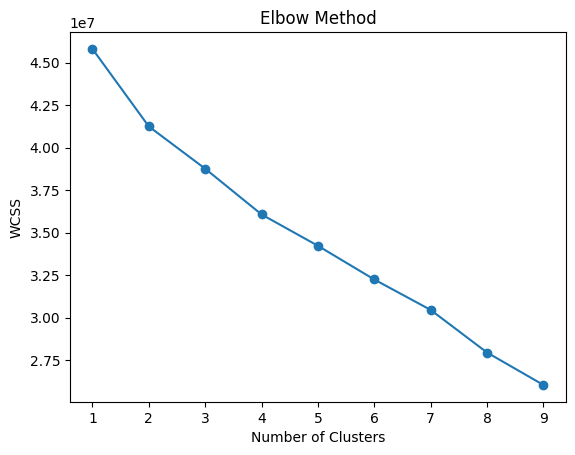

In [ ]:
# Cell 4: Elbow Method

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

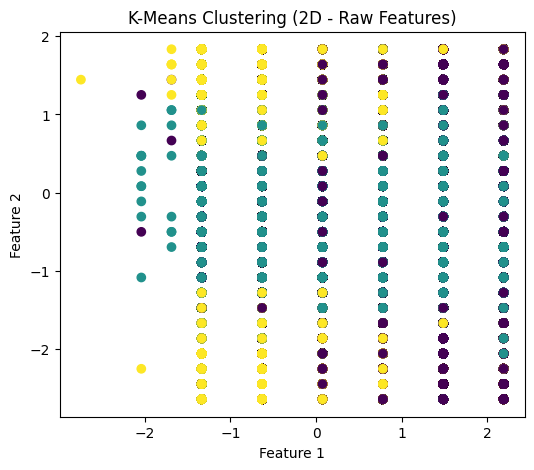

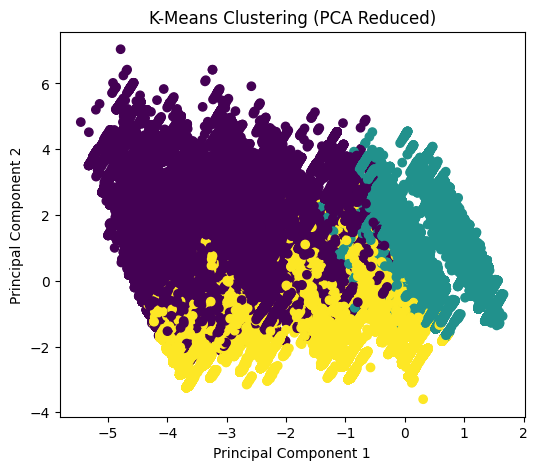

In [ ]:
# Cell5: K-Means + 2D Plot + PCA Plot
# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_scaled)

df_selected['Cluster'] = clusters

# -------------------------------
# 🔹 1. Simple 2D Plot (Original Features)
# -------------------------------
plt.figure(figsize=(6,5))
plt.scatter(df_scaled[:, 0], df_scaled[:, 1], c=clusters, cmap='viridis')
plt.title('K-Means Clustering (2D - Raw Features)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


# -------------------------------
# 🔹 2. PCA Plot (Better Visualization)
# -------------------------------
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(6,5))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=clusters, cmap='viridis')
plt.title('K-Means Clustering (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [ ]:
# Cell 6: Improved Cluster Interpretation + Labeling (FINAL)

# 🔹 Align original data properly
df_original = df.loc[df_selected.index].copy()
df_original['Cluster'] = df_selected['Cluster']

# 🔹 Analyze distributions
categorical_cols = [
    'Weather_Conditions',
    'Road_Surface_Conditions',
    'Road_Type',
    'Light_Conditions',
    'Urban_or_Rural_Area'
]

for col in categorical_cols:
    print(f"\n🔹 {col} distribution per cluster:\n")
    grouped = df_original.groupby('Cluster')[col].value_counts()
    print(grouped.groupby(level=0).head(3))


# 🔹 FINAL LABELING

def label_cluster(cluster):
    if cluster == 0:
        return 'Adverse Weather & Wet Road Conditions'
    elif cluster == 1:
        return 'Normal Driving Conditions (Urban Daylight)'
    else:
        return 'Low Visibility / Night Driving Conditions'

df_selected['Cluster_Label'] = df_selected['Cluster'].apply(label_cluster)

print(df_selected[['Cluster', 'Cluster_Label']].head())


🔹 Weather_Conditions distribution per cluster:

Cluster  Weather_Conditions   
0        Raining no high winds     179305
         Fine no high winds         76148
         Other                      32743
1        Fine no high winds       1254039
         Fine + high winds          10405
2        Fine no high winds        299563
         Raining no high winds      58616
         Other                      10774
Name: count, dtype: int64

🔹 Road_Surface_Conditions distribution per cluster:

Cluster  Road_Surface_Conditions
0        Wet or damp                 255001
         Dry                          57004
         Frost or ice                 16555
1        Dry                        1093662
         Wet or damp                 154782
         Frost or ice                 14572
2        Dry                         227449
         Wet or damp                 149496
         Frost or ice                  8478
Name: count, dtype: int64

🔹 Road_Type distribution per cluster:

Cluster  

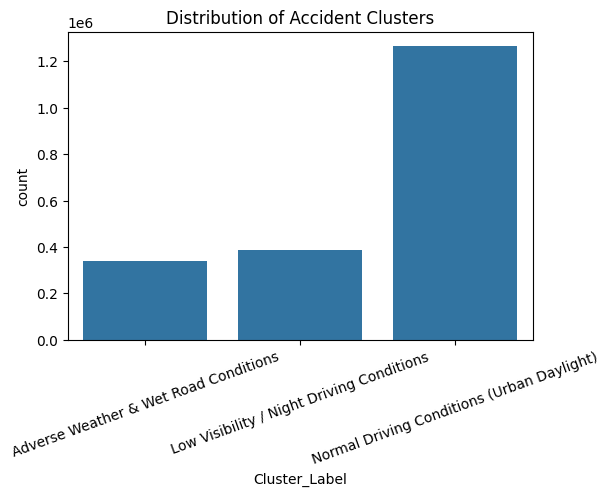


🔹 Severity Distribution (Counts):

Accident_Severity                           Fatal  Serious   Slight
Cluster_Label                                                      
Adverse Weather & Wet Road Conditions        7023    48467   286050
Low Visibility / Night Driving Conditions    5224    59352   321232
Normal Driving Conditions (Urban Daylight)  13659   172840  1077945

🔹 Severity Distribution (Percentage):

Accident_Severity                              Fatal   Serious    Slight
Cluster_Label                                                           
Adverse Weather & Wet Road Conditions       0.020563  0.141907  0.837530
Low Visibility / Night Driving Conditions   0.013540  0.153838  0.832621
Normal Driving Conditions (Urban Daylight)  0.010802  0.136692  0.852505


In [ ]:
# Cell 7: Visualization + Severity Analysis (Improved)

# 🔹 Cluster distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Cluster_Label', data=df_selected)
plt.title('Distribution of Accident Clusters')
plt.xticks(rotation=20)
plt.show()

# 🔹 Add severity (aligned correctly)
df_selected['Accident_Severity'] = df.loc[df_selected.index, 'Accident_Severity']

# 🔹 Severity counts
severity_analysis = pd.crosstab(
    df_selected['Cluster_Label'],
    df_selected['Accident_Severity']
)

print("\n🔹 Severity Distribution (Counts):\n")
print(severity_analysis)


# 🔹 Severity percentages (VERY IMPORTANT FOR VIVA)
severity_percent = severity_analysis.div(severity_analysis.sum(axis=1), axis=0)

print("\n🔹 Severity Distribution (Percentage):\n")
print(severity_percent)

This project applied K-Means clustering to analyze road accident patterns based on environmental and road-related factors such as weather conditions, road surface, lighting, location type, and time of occurrence.

The clustering results revealed three meaningful groups of accident scenarios:

Adverse Weather & Wet Road Conditions showed the highest fatality rate (≈2.05%), indicating that poor weather and slippery roads significantly increase accident severity.
Low Visibility / Night Driving Conditions exhibited the highest proportion of serious injuries (≈15.38%), suggesting that reduced visibility contributes to more severe but not always fatal accidents.
Favourable Driving Conditions (Urban Daylight) had the lowest fatality rate (≈1.08%), making it the safest cluster despite having the highest number of total accidents.

It is important to note that although the favourable conditions cluster recorded the highest number of fatal accidents, this is due to its significantly larger size. When normalized using percentages, it is actually the least risky environment per accident. This highlights that accident frequency is influenced by exposure (higher traffic in normal conditions), whereas accident severity is more influenced by environmental risk factors.

Overall, the analysis demonstrates that accident risk is not evenly distributed and depends on multiple interacting factors such as weather, lighting, and road conditions. Clustering helped uncover these hidden patterns, providing insights that can support road safety improvements, such as better infrastructure in rural and wet conditions, and enhanced visibility measures for night-time driving.